# Module 07 - Self-Attention

This notebook is for making the attention mechanism concrete after the package tests pass. The goal is not to build a polished language model yet. The goal is to see queries, keys, values, masks, attention weights, and the quadratic cost in live tensors.

1. Read the lesson page (`docs/modules/07-attention.md`).
2. Open this notebook with `.venv/bin/python scripts/open_notebook.py 07`.
3. Answer the `Question:` / `Answer:` cells below.
4. When you're ready, ask a coding agent to grade your notebook.

Partial work is fine. Blank `Answer: ""` strings are skipped, not counted wrong. If you'd like a hint instead of a grade, write the request inline in the answer string and the agent will tutor first.

In [1]:
from __future__ import annotations

import contextlib
import io
import math
import subprocess
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import torch

import g2c
from g2c.artifacts import load_model_artifact_with_tokenizer, model_artifact_exists
from g2c.attention import SelfAttention
from g2c.embeddings import LearnedPositionalEmbedding, TokenEmbedding
from g2c.nn import CrossEntropyLoss, Linear, Module, SGD, resolve_device
from g2c.tokenizer import BPETokenizer
from g2c.training import AdamW

_ = torch.manual_seed(0)
repo_root = Path(g2c.__file__).resolve().parents[1]
experiment_device = "auto"
print("MPS available:", torch.backends.mps.is_available())

MPS available: True


## Before the Notebook

Implement `SelfAttention.forward` and `SelfAttention.attention_weights` first. The notebook assumes the Module 07 tests are green, because the experiments below call those public methods directly.

In [2]:
"Run from the terminal: .venv/bin/python -m pytest tests/test_attention.py -x"
"Question: Which attention test is the next one failing, and what implementation detail does it point at?"
"Answer: "

'Answer: '

In [3]:
result = subprocess.run(
    [sys.executable, "-m", "pytest", "tests/test_attention.py"],
    cwd=repo_root,
    text=True,
    capture_output=True,
)
print(result.stdout)
if result.stderr:
    print(result.stderr)

assert result.returncode == 0, "Module 07 attention tests are not passing yet."
print("Module 07 attention tests passed.")

.......................                                                  [100%]
23 passed in 1.83s

Module 07 attention tests passed.


## Exercise 1 - A Three-Token Attention Pass by Hand

Start with one batch, three positions, and two channels. Before running the check cell, write down the expected shapes of Q, K, V, scores, weights, and output. Then compare the manual tensor pipeline to `SelfAttention.forward`.

In [4]:
"Question: For x shaped (1, 3, 2), what shape should Q @ K.T have?"
"Answer: "

"Question: Which dimension should softmax normalize over, and why?"
"Answer: "

"Question: Why does causal=False make this hand check easier?"
"Answer: "

'Answer: '

In [5]:
toy_x = torch.tensor([[[1.0, 0.0], [0.0, 1.0], [1.0, 1.0]]])
toy_attn = SelfAttention(embedding_dim=2, causal=False)

q = toy_attn.q_proj(toy_x)
k = toy_attn.k_proj(toy_x)
v = toy_attn.v_proj(toy_x)
scores = q @ k.transpose(-2, -1) / math.sqrt(toy_attn.embedding_dim)
weights = scores.softmax(dim=-1)
manual_out = toy_attn.out_proj(weights @ v)
module_out = toy_attn(toy_x)

print("q shape:", tuple(q.shape))
print("scores shape:", tuple(scores.shape))
print("attention weights:")
print(weights[0].detach())
print("max absolute diff:", (manual_out - module_out).abs().max().item())

assert torch.allclose(manual_out, module_out, atol=1e-5)

q shape: (1, 3, 2)
scores shape: (1, 3, 3)
attention weights:
tensor([[0.3062, 0.3379, 0.3559],
        [0.3842, 0.3014, 0.3144],
        [0.3550, 0.3073, 0.3377]])
max absolute diff: 0.0


## Exercise 2 - Visualize Attention on Two Sentences

These weights are from an untrained random attention layer, so this is a **negative control**. You should not see a semantic pattern yet. The point is to make the visualization plumbing real: tokenize, embed, add position, call `attention_weights`, and plot the `(T, T)` matrix.

The raw probability heatmap uses a fixed color scale so a nearly-uniform random layer does not get visually exaggerated. The second row subtracts the uniform baseline `1 / T`, which makes tiny random deviations visible without implying the model understands the sentence.

In [6]:
"Question: Why should random attention weights not resolve what 'it' refers to yet?"
"Answer: "

"Question: What would you hope to see after training on enough text?"
"Answer: "

'Answer: '

'the animal did not cross the street because it was too tired': T=27, uniform=0.0370, max=0.0389, max above uniform=0.0018
'the animal did not cross the street because it was too wide': T=27, uniform=0.0370, max=0.0388, max above uniform=0.0018


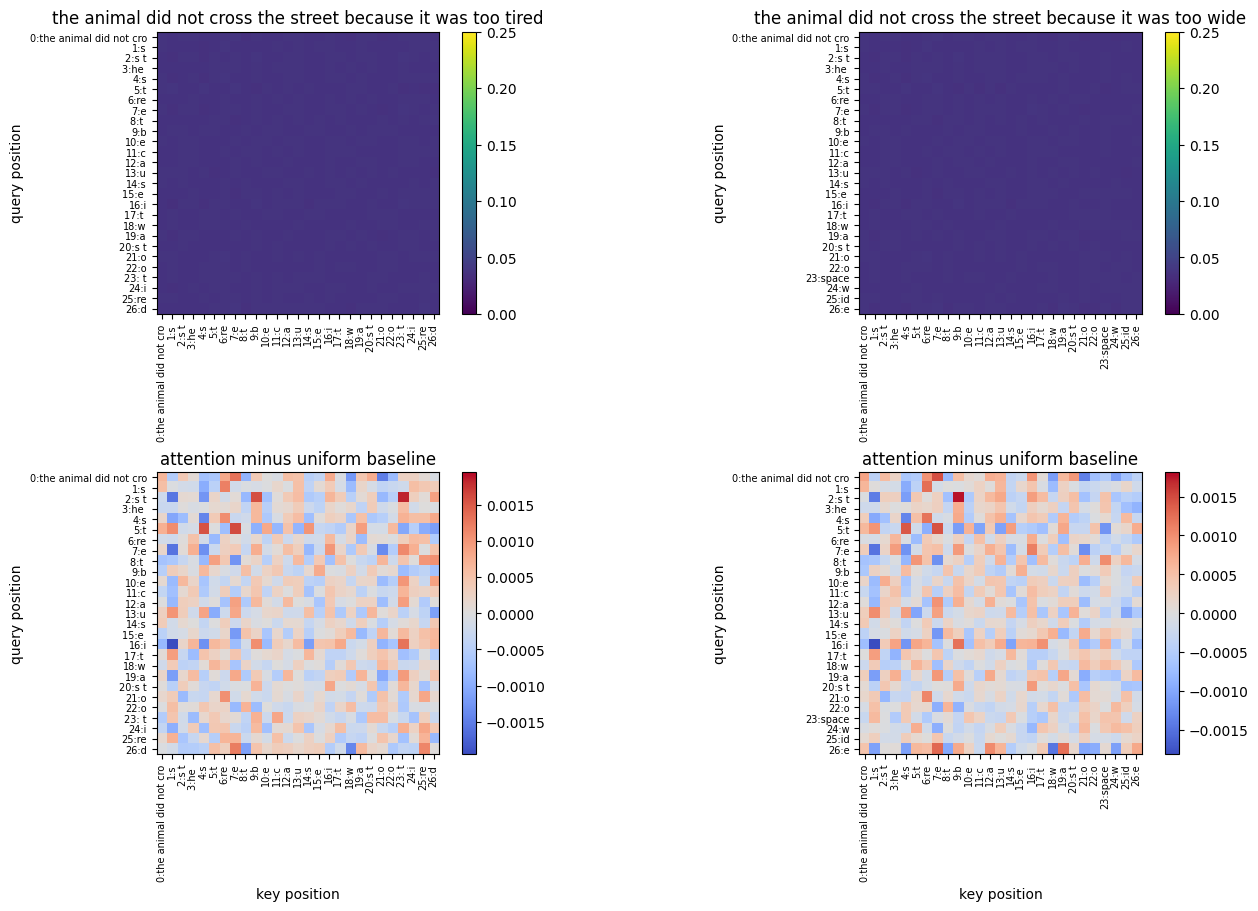

In [7]:
attention_sentences = [
    "the animal did not cross the street because it was too tired",
    "the animal did not cross the street because it was too wide",
]
attention_corpus = "\n".join(attention_sentences)

tokenizer = BPETokenizer()
with contextlib.redirect_stdout(io.StringIO()):
    tokenizer.train(attention_corpus, vocab_size=280)

def token_labels(ids: list[int]) -> list[str]:
    labels = []
    for i, token_id in enumerate(ids):
        piece = tokenizer.decode([int(token_id)]).replace("\n", "\\n")
        if piece == " ":
            piece = "space"
        labels.append(f"{i}:{piece}")
    return labels

embedding_dim = 16
token_embed = TokenEmbedding(vocab_size=len(tokenizer.vocab), embedding_dim=embedding_dim)
pos_embed = LearnedPositionalEmbedding(max_seq_len=128, embedding_dim=embedding_dim)
viz_attn = SelfAttention(embedding_dim=embedding_dim, causal=False)

def sentence_attention(sentence: str) -> tuple[torch.Tensor, list[str]]:
    ids = tokenizer.encode(sentence)
    ids_tensor = torch.tensor(ids, dtype=torch.long).unsqueeze(0)
    x = token_embed(ids_tensor) + pos_embed(ids_tensor.shape[1]).unsqueeze(0)
    weights = viz_attn.attention_weights(x)[0].detach()
    return weights, token_labels(ids)

fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)
for column, sentence in enumerate(attention_sentences):
    weights, labels = sentence_attention(sentence)
    uniform = 1.0 / weights.shape[-1]
    deviation = weights - uniform
    dev_limit = max(float(deviation.abs().max()), 1e-6)

    print(
        f"{sentence!r}: T={weights.shape[-1]}, uniform={uniform:.4f}, "
        f"max={float(weights.max()):.4f}, max above uniform={float(deviation.max()):.4f}"
    )

    prob_ax = axes[0, column]
    prob_image = prob_ax.imshow(weights, vmin=0.0, vmax=0.25, cmap="viridis")
    prob_ax.set_title(sentence)
    prob_ax.set_ylabel("query position")
    fig.colorbar(prob_image, ax=prob_ax, fraction=0.046, pad=0.04)

    dev_ax = axes[1, column]
    dev_image = dev_ax.imshow(deviation, vmin=-dev_limit, vmax=dev_limit, cmap="coolwarm")
    dev_ax.set_title("attention minus uniform baseline")
    dev_ax.set_xlabel("key position")
    dev_ax.set_ylabel("query position")
    fig.colorbar(dev_image, ax=dev_ax, fraction=0.046, pad=0.04)

    for ax in (prob_ax, dev_ax):
        ax.set_xticks(range(len(labels)))
        ax.set_yticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=90, fontsize=7)
        ax.set_yticklabels(labels, fontsize=7)
plt.show()

## Optional Probe - Train Attention on TinyShakespeare

The random sentence heatmap is a negative control. This optional probe gives you a positive control without waiting for the full Module 10 milestone: train a tiny character-level causal attention model on TinyShakespeare for a short run, then compare the same model's attention before and after training.

This is still not semantic interpretability. We are looking for a simpler fact: training should make attention sharper and less like the causal-uniform baseline.

In [8]:
"Question: What changes between the before-training and after-training attention maps?"
"Answer: "

"Question: Why is sharper trained attention still not the same thing as semantic understanding?"
"Answer: "

'Answer: '

In [9]:
class TinyShakespeareAttentionProbe(Module):
    def __init__(self, vocab_size: int, seq_len: int, embedding_dim: int) -> None:
        super().__init__()
        self.vocab_size = vocab_size
        self.seq_len = seq_len
        self.embedding_dim = embedding_dim
        self.embed = TokenEmbedding(vocab_size, embedding_dim)
        self.pos = LearnedPositionalEmbedding(seq_len, embedding_dim)
        self.attn = SelfAttention(embedding_dim, causal=True)
        self.out = Linear(embedding_dim, vocab_size)

    def parameters(self):
        return [
            *self.embed.parameters(),
            *self.pos.parameters(),
            *self.attn.parameters(),
            *self.out.parameters(),
        ]

    def forward(self, ids: torch.Tensor) -> torch.Tensor:
        T = ids.shape[1]
        x = self.embed(ids) + self.pos(T).unsqueeze(0)
        x = self.attn(x)
        return self.out(x)

    def attention_weights_for_ids(self, ids: torch.Tensor) -> torch.Tensor:
        T = ids.shape[1]
        x = self.embed(ids) + self.pos(T).unsqueeze(0)
        return self.attn.attention_weights(x)


def load_tinyshakespeare_chars(max_chars: int = 200_000):
    path = repo_root / "data" / "tinyshakespeare.txt"
    if not path.exists():
        return None
    text = path.read_text(encoding="utf-8")[:max_chars]
    chars = sorted(set(text))
    char_to_id = {ch: i for i, ch in enumerate(chars)}
    id_to_char = {i: ch for ch, i in char_to_id.items()}
    ids = torch.tensor([char_to_id[ch] for ch in text], dtype=torch.long)
    return text, ids, char_to_id, id_to_char


def get_char_batch(ids: torch.Tensor, seq_len: int, batch_size: int, *, generator=None):
    starts = torch.randint(0, len(ids) - seq_len - 1, (batch_size,), generator=generator)
    x = torch.stack([ids[s : s + seq_len] for s in starts])
    y = torch.stack([ids[s + 1 : s + seq_len + 1] for s in starts])
    return x, y


def attention_entropy(weights: torch.Tensor) -> float:
    return float((-(weights * (weights + 1e-9).log()).sum(dim=-1)).mean())


def causal_uniform_matrix(seq_len: int) -> torch.Tensor:
    baseline = torch.zeros(seq_len, seq_len)
    for row in range(seq_len):
        baseline[row, : row + 1] = 1.0 / (row + 1)
    return baseline


def char_axis_labels(text: str) -> list[str]:
    labels = []
    for i, ch in enumerate(text):
        piece = ch.replace("\n", "\\n")
        if piece == " ":
            piece = "space"
        labels.append(f"{i}:{piece}")
    return labels


def train_attention_probe(
    model: TinyShakespeareAttentionProbe,
    ids: torch.Tensor,
    *,
    steps: int = 600,
    batch_size: int = 128,
    lr: float = 3e-3,
    log_every: int = 100,
    seed: int = 0,
    device=experiment_device,
) -> tuple[list[int], list[float]]:
    device = resolve_device(device)
    model.to(device)
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    loss_fn = CrossEntropyLoss()
    generator = torch.Generator().manual_seed(seed)
    logged_steps: list[int] = []
    losses: list[float] = []

    for step in range(steps):
        x, y = get_char_batch(ids, model.seq_len, batch_size, generator=generator)
        x = x.to(device)
        y = y.to(device)
        logits = model(x)
        loss = loss_fn(logits.reshape(-1, model.vocab_size), y.reshape(-1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if step % log_every == 0 or step == steps - 1:
            logged_steps.append(step)
            losses.append(float(loss.detach().cpu()))
    return logged_steps, losses


trained for 17.2s on mps
loss: [4.128, 3.04, 2.666, 2.586, 2.448, 2.389, 2.332]
mean max attention before/after: 0.077 0.782
mean attention entropy before/after: 3.16 0.653


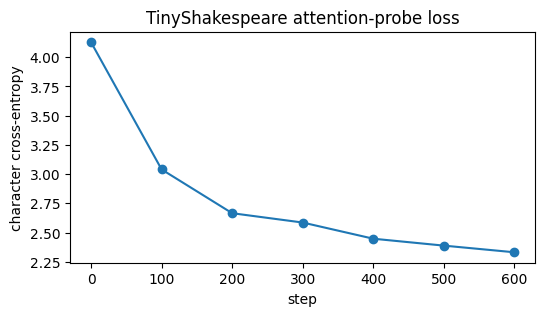

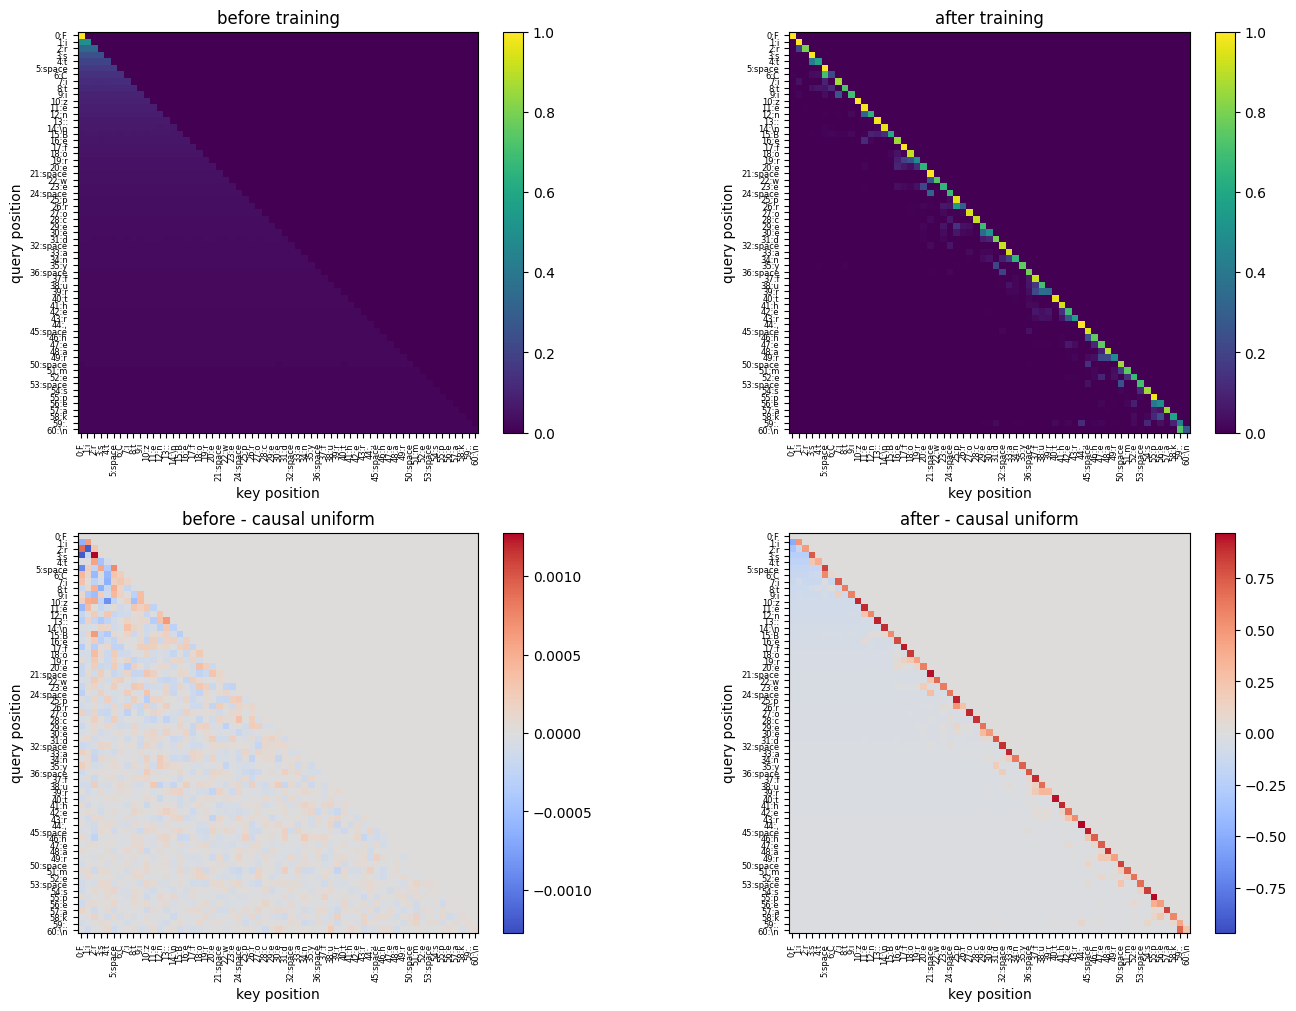

In [10]:
probe_data = load_tinyshakespeare_chars()
if probe_data is None:
    print("Skipping TinyShakespeare attention probe: run ./setup.sh first.")
else:
    _, shakespeare_ids, char_to_id, id_to_char = probe_data
    probe_seq_len = 64
    probe_prompt = "First Citizen:\nBefore we proceed any further, hear me speak.\n"
    probe_prompt = probe_prompt[:probe_seq_len]
    probe_prompt_ids = torch.tensor(
        [[char_to_id.get(ch, char_to_id[" "]) for ch in probe_prompt]],
        dtype=torch.long,
    )

    _ = torch.manual_seed(7)
    probe_model = TinyShakespeareAttentionProbe(
        vocab_size=len(char_to_id),
        seq_len=probe_seq_len,
        embedding_dim=64,
    )
    probe_device = resolve_device(experiment_device)
    probe_model.to(probe_device)
    before_weights = probe_model.attention_weights_for_ids(
        probe_prompt_ids.to(probe_device)
    )[0].detach().cpu()

    start = time.perf_counter()
    probe_steps, probe_losses = train_attention_probe(
        probe_model,
        shakespeare_ids,
        steps=600,
        batch_size=128,
        lr=3e-3,
        log_every=100,
    )
    elapsed = time.perf_counter() - start
    after_weights = probe_model.attention_weights_for_ids(
        probe_prompt_ids.to(probe_device)
    )[0].detach().cpu()

    print(f"trained for {elapsed:.1f}s on {probe_device}")
    print("loss:", [round(x, 3) for x in probe_losses])
    print(
        "mean max attention before/after:",
        round(float(before_weights.max(dim=-1).values.mean()), 3),
        round(float(after_weights.max(dim=-1).values.mean()), 3),
    )
    print(
        "mean attention entropy before/after:",
        round(attention_entropy(before_weights), 3),
        round(attention_entropy(after_weights), 3),
    )

    plt.figure(figsize=(6, 3))
    plt.plot(probe_steps, probe_losses, marker="o")
    plt.title("TinyShakespeare attention-probe loss")
    plt.xlabel("step")
    plt.ylabel("character cross-entropy")
    plt.show()

    labels = char_axis_labels(probe_prompt)
    baseline = causal_uniform_matrix(len(labels))
    panels = [
        ("before training", before_weights, "viridis", 0.0, 1.0),
        ("after training", after_weights, "viridis", 0.0, 1.0),
        ("before - causal uniform", before_weights - baseline, "coolwarm", None, None),
        ("after - causal uniform", after_weights - baseline, "coolwarm", None, None),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
    for ax, (title, matrix, cmap, vmin, vmax) in zip(axes.flat, panels):
        if vmin is None or vmax is None:
            limit = max(float(matrix.abs().max()), 1e-6)
            vmin, vmax = -limit, limit
        image = ax.imshow(matrix, vmin=vmin, vmax=vmax, cmap=cmap)
        ax.set_title(title)
        ax.set_xlabel("key position")
        ax.set_ylabel("query position")
        ax.set_xticks(range(len(labels)))
        ax.set_yticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=90, fontsize=6)
        ax.set_yticklabels(labels, fontsize=6)
        fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    plt.show()


## Optional Revisit - Inspect a Trained ShakespeareLM Head

After Module 10 has saved `ShakespeareLM`, you can come back and run a short forward pass through the trained model. This is the same heatmap plumbing as Exercise 2, but now the weights come from a model that has actually trained on TinyShakespeare.

This is optional and safely skips if no artifact exists yet. Do not expect clean human-readable explanations from one tiny trained head. The useful question is narrower: did training move attention away from the random near-uniform baseline?

In [11]:
"Question: Why is a trained ShakespeareLM attention map still not proof that the model understands a sentence semantically?"
"Answer: "

"Question: Why does this optional revisit belong after Module 10 rather than on the first Module 07 pass?"
"Answer: "

'Answer: '

head 0 top keys for final token: [('15:B', 0.041), ('46:h', 0.039), ('10:z', 0.038)]
head 1 top keys for final token: [('44:,', 0.107), ('46:h', 0.075), ('47:e', 0.057)]
head 2 top keys for final token: [('0:F', 0.025), ('31:d', 0.024), ('3:s', 0.023)]
head 3 top keys for final token: [('44:,', 0.119), ('46:h', 0.106), ('45:space', 0.096)]


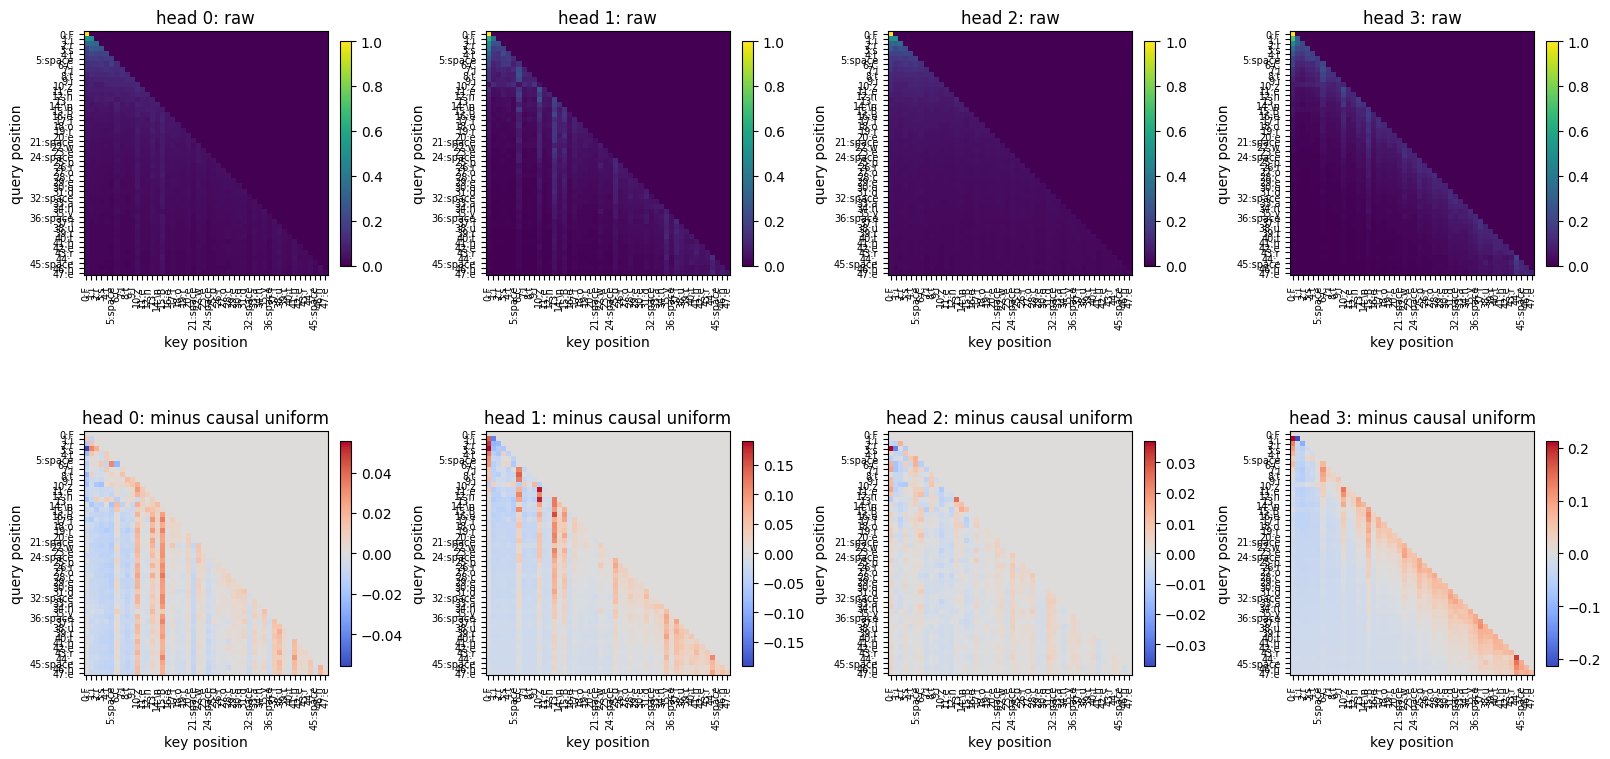

In [12]:
def choose_shakespeare_artifact_name() -> str | None:
    for name in ("ShakespeareLM-1M", "ShakespeareLM"):
        if model_artifact_exists(name, repo_root=repo_root):
            return name
    return None


def transformer_layer_attention_weights(model, token_ids: torch.Tensor, *, layer_index: int = 0):
    """Return (heads, T, T) attention weights from one TransformerLM layer."""
    B, T = token_ids.shape
    x = model.token_embed(token_ids) + model.pos_embed(T).unsqueeze(0)
    for index, block in enumerate(model.blocks):
        normalized = block.ln1(x)
        if index == layer_index:
            return block.attn.attention_weights(normalized)[0].detach()
        x = x + block.attn(normalized)
        x = x + block.ffn(block.ln2(x))
    raise ValueError(f"layer_index {layer_index} is out of range")


def trained_token_labels(tokenizer, ids: list[int]) -> list[str]:
    labels = []
    for i, token_id in enumerate(ids):
        piece = tokenizer.decode([int(token_id)]).replace("\n", "\\n")
        if piece == " ":
            piece = "space"
        if len(piece) > 12:
            piece = piece[:9] + "..."
        labels.append(f"{i}:{piece}")
    return labels


artifact_name = choose_shakespeare_artifact_name()
if artifact_name is None:
    print("Skipping trained attention pass: run Module 10 and save ShakespeareLM first.")
else:
    loaded = load_model_artifact_with_tokenizer(artifact_name, repo_root=repo_root)
    trained_model = loaded.model
    trained_tokenizer = loaded.tokenizer
    trained_prompt = "First Citizen:\nBefore we proceed any further, hear me speak."
    trained_ids = trained_tokenizer.encode_with_vocab_size(trained_prompt, trained_model.vocab_size)
    trained_ids = trained_ids[: min(len(trained_ids), trained_model.max_seq_len, 48)]
    trained_tensor = torch.tensor(trained_ids, dtype=torch.long).unsqueeze(0)
    trained_weights = transformer_layer_attention_weights(trained_model, trained_tensor, layer_index=0)
    trained_labels = trained_token_labels(trained_tokenizer, trained_ids)

    T = trained_weights.shape[-1]
    causal_uniform = torch.zeros(T, T)
    for row in range(T):
        causal_uniform[row, : row + 1] = 1.0 / (row + 1)

    heads_to_show = min(4, trained_weights.shape[0])
    fig, axes = plt.subplots(2, heads_to_show, figsize=(4 * heads_to_show, 8), constrained_layout=True)
    if heads_to_show == 1:
        axes = axes.reshape(2, 1)

    for head in range(heads_to_show):
        raw = trained_weights[head]
        deviation = raw - causal_uniform
        dev_limit = max(float(deviation.abs().max()), 1e-6)

        raw_ax = axes[0, head]
        raw_image = raw_ax.imshow(raw, vmin=0.0, vmax=1.0, cmap="viridis")
        raw_ax.set_title(f"head {head}: raw")
        fig.colorbar(raw_image, ax=raw_ax, fraction=0.046, pad=0.04)

        dev_ax = axes[1, head]
        dev_image = dev_ax.imshow(deviation, vmin=-dev_limit, vmax=dev_limit, cmap="coolwarm")
        dev_ax.set_title(f"head {head}: minus causal uniform")
        fig.colorbar(dev_image, ax=dev_ax, fraction=0.046, pad=0.04)

        for ax in (raw_ax, dev_ax):
            ax.set_xlabel("key position")
            ax.set_ylabel("query position")
            ax.set_xticks(range(T))
            ax.set_yticks(range(T))
            ax.set_xticklabels(trained_labels, rotation=90, fontsize=7)
            ax.set_yticklabels(trained_labels, fontsize=7)

        top = torch.topk(raw[-1], k=min(3, T))
        top_items = [(trained_labels[int(i)], round(float(v), 3)) for v, i in zip(top.values, top.indices)]
        print(f"head {head} top keys for final token:", top_items)

    plt.show()


## Exercise 3 - The Strip-Mask Cheat

This experiment uses a sequence-wide language-modeling objective: input positions `0..T-1` predict targets `1..T`. With `causal=False`, position `t` can attend to input position `t+1`, which is exactly the target for that row. With `causal=True`, it cannot. The loss below ignores the final position because its target is outside the input window in both settings; the point is to isolate the rows where future-token leakage exists.

That leakage does **not** show up with Module 06's `train_lm` last-position interface, because the target token is outside the input window. The all-positions setup below is the standard transformer LM training shape where the causal mask is load-bearing.

In [13]:
"Question: Why does the non-causal model have access to the answer in this setup?"
"Answer: "

"Question: Why would a suspiciously perfect training curve be a red flag in an LM?"
"Answer: "

'Answer: '

In [14]:
class TinySequenceAttentionLM(Module):
    def __init__(self, vocab_size: int, seq_len: int, embedding_dim: int, *, causal: bool) -> None:
        super().__init__()
        self.vocab_size = vocab_size
        self.seq_len = seq_len
        self.embedding_dim = embedding_dim
        self.embed = TokenEmbedding(vocab_size, embedding_dim)
        self.pos = LearnedPositionalEmbedding(seq_len, embedding_dim)
        self.attn = SelfAttention(embedding_dim, causal=causal)
        self.out = Linear(embedding_dim, vocab_size)

    def parameters(self):
        return [
            *self.embed.parameters(),
            *self.pos.parameters(),
            *self.attn.parameters(),
            *self.out.parameters(),
        ]

    def forward(self, ids: torch.Tensor) -> torch.Tensor:
        B, T = ids.shape
        x = self.embed(ids) + self.pos(T).unsqueeze(0)
        x = self.attn(x)
        return self.out(x)


def get_sequence_batch(ids: torch.Tensor, seq_len: int, batch_size: int, *, generator=None):
    starts = torch.randint(0, len(ids) - seq_len - 1, (batch_size,), generator=generator)
    x = torch.stack([ids[s : s + seq_len] for s in starts])
    y = torch.stack([ids[s + 1 : s + seq_len + 1] for s in starts])
    return x, y


def sequence_loss(logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
    # Ignore the last row: its target is not present in the input window.
    logits = logits[:, :-1, :]
    targets = targets[:, :-1]
    return CrossEntropyLoss()(logits.reshape(-1, logits.shape[-1]), targets.reshape(-1))


def train_sequence_model(model, ids, *, steps=500, batch_size=128, lr=0.5, log_every=50, seed=0, device=experiment_device):
    device = resolve_device(device)
    model.to(device)
    optimizer = SGD(model.parameters(), lr=lr)
    losses = []
    generator = torch.Generator().manual_seed(seed)
    for step in range(steps):
        x, y = get_sequence_batch(ids, model.seq_len, batch_size, generator=generator)
        x = x.to(device)
        y = y.to(device)
        logits = model(x)
        loss = sequence_loss(logits, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if step % log_every == 0 or step == steps - 1:
            losses.append(float(loss.item()))
    return losses

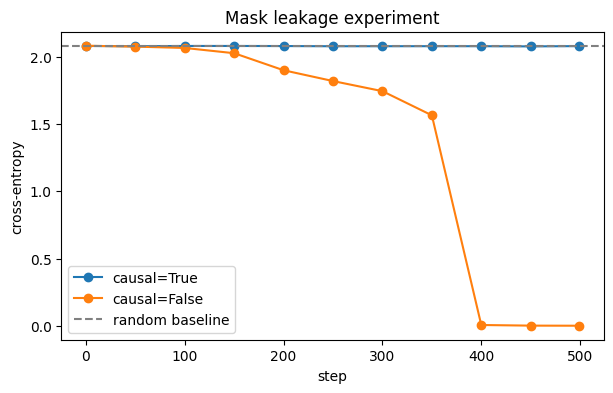

final causal loss: 2.0786049365997314
final non-causal loss: 0.0009396917303092778


In [15]:
random_vocab_size = 8
random_stream = torch.randint(
    0,
    random_vocab_size,
    (4096,),
    generator=torch.Generator().manual_seed(7),
)

strip_seq_len = 8
strip_steps = 500
strip_log_every = 50

causal_lm = TinySequenceAttentionLM(random_vocab_size, strip_seq_len, 32, causal=True)
noncausal_lm = TinySequenceAttentionLM(random_vocab_size, strip_seq_len, 32, causal=False)

causal_losses = train_sequence_model(
    causal_lm,
    random_stream,
    steps=strip_steps,
    log_every=strip_log_every,
    seed=1,
)
noncausal_losses = train_sequence_model(
    noncausal_lm,
    random_stream,
    steps=strip_steps,
    log_every=strip_log_every,
    seed=2,
)

strip_steps_logged = list(range(0, strip_steps, strip_log_every))
if strip_steps_logged[-1] != strip_steps - 1:
    strip_steps_logged.append(strip_steps - 1)

plt.figure(figsize=(7, 4))
plt.plot(strip_steps_logged, causal_losses, marker="o", label="causal=True")
plt.plot(strip_steps_logged, noncausal_losses, marker="o", label="causal=False")
plt.axhline(math.log(random_vocab_size), color="0.5", linestyle="--", label="random baseline")
plt.title("Mask leakage experiment")
plt.xlabel("step")
plt.ylabel("cross-entropy")
plt.legend()
plt.show()

print("final causal loss:", causal_losses[-1])
print("final non-causal loss:", noncausal_losses[-1])

## Exercise 4 - Parameter Count

The attention layer has four `Linear(D, D)` projections: Q, K, V, and output. That means the parameter count is `4 * (D * D + D)` and does not depend on sequence length.

In [16]:
"Question: Why does the parameter count not depend on T?"
"Answer: "

"Question: If parameters do not grow with T, what part of attention still gets expensive as T grows?"
"Answer: "

'Answer: '

In [17]:
print("D    expected    actual")
print("-" * 28)
for D in [64, 128, 256, 512]:
    attn = SelfAttention(embedding_dim=D)
    expected = 4 * (D * D + D)
    actual = sum(p.numel() for p in attn.parameters())
    print(f"{D:<4d} {expected:<10d} {actual:<10d}")
    assert expected == actual

D    expected    actual
----------------------------
64   16640      16640     
128  66048      66048     
256  263168     263168    
512  1050624    1050624   


## Exercise 5 - Feel the Quadratic Cost

The score tensor is shaped `(B, T, T)`. This timing cell keeps `D` fixed and increases `T`. The default sizes are conservative for a notebook; add larger values if your machine is comfortable.

In [18]:
"Question: Why should a log-log time plot bend toward slope 2 as T grows?"
"Answer: "

"Question: Why might small T values not show a clean quadratic trend?"
"Answer: "

'Answer: '

T=64    seconds=0.00021
T=128   seconds=0.00018
T=256   seconds=0.00048
T=512   seconds=0.00095


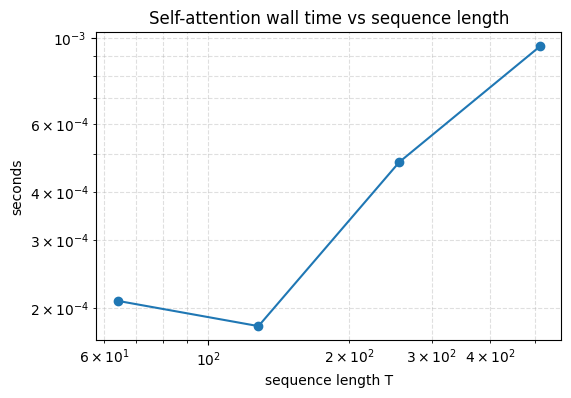

In [19]:
timing_attn = SelfAttention(embedding_dim=128, causal=True)
timing_lengths = [64, 128, 256, 512]
timing_seconds = []

for T in timing_lengths:
    x = torch.randn(1, T, 128)
    _ = timing_attn(x)
    start = time.perf_counter()
    with torch.no_grad():
        _ = timing_attn(x)
    elapsed = time.perf_counter() - start
    timing_seconds.append(elapsed)
    print(f"T={T:<5d} seconds={elapsed:.5f}")

plt.figure(figsize=(6, 4))
plt.loglog(timing_lengths, timing_seconds, marker="o")
plt.title("Self-attention wall time vs sequence length")
plt.xlabel("sequence length T")
plt.ylabel("seconds")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.show()